This model predicts a product's rating (stars) based on its features.

**Features used to determine ratings:**
- `discount_percentage` - How much the product is marked down
- `rating_count` - Number of customer reviews
- `deal_score` - How good the deal is (calculated by Amazon)
- `savings_INR` - Money saved (actual price - discounted price)

In [11]:
# Loading data containing product ratings and features
import pandas as pd
df = pd.read_csv('amazon_cleaned_dataset.csv')
print(df.shape)
df.head(2)

(1465, 17)


,product_id,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,main_category,sub_category,savings_INR,weighted_rating,deal_score,price_tier,main_category_enc,sub_category_enc,price_tier_enc
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,399.0,1099.0,0.64,4.2,24269,High Compatibility : Compatible With iPhone 12...,Computers & Accessories,USB Cables,700.0,42.407384,2.688,Budget,1,190,0.0
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,199.0,349.0,0.43,4.0,43994,"Compatible with all Type C enabled devices, be...",Computers & Accessories,USB Cables,150.0,42.767325,1.720,Budget,1,190,0.0


In [12]:
# Selecting features and splitting data for training
# Features: discount percentage, number of ratings, deal score, and savings in INR
from sklearn.model_selection import train_test_split

features = ['discount_percentage', 'rating_count', 'deal_score', 'savings_INR']
target = 'rating'

X = df[features].fillna(0)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1172, 4), Test: (293, 4)


In [13]:
# Train Random Forest model and evaluating performance
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")

MAE: 0.089
R² Score: 0.728


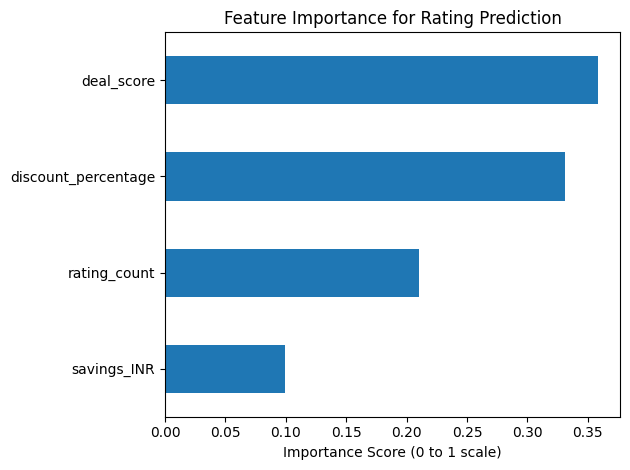

Note: Scores sum to 1.0. Higher score = more influence on predictions.


In [23]:
# Visualizing which features most influence product ratings
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')
plt.xlabel('Importance Score (0 to 1 scale)')
plt.title('Feature Importance for Rating Prediction')
plt.tight_layout()
plt.show()

print("Note: Scores sum to 1.0. Higher score = more influence on predictions.")

Ratings range from 3.0 to 5.0 stars. Higher = better product.

In [25]:
# Testing the model with custom inputs
def predict_rating(discount, rating_count, deal_score, savings):
    import numpy as np
    import pandas as pd
    from sklearn.utils.validation import check_array

    # Creating DataFrame with feature names to avoid warning
    input_data = pd.DataFrame([[discount, rating_count, deal_score, savings]],
                              columns=['discount_percentage', 'rating_count', 'deal_score', 'savings_INR'])
    pred = model.predict(input_data)
    return round(pred[0], 2)

# Example
print(f"Predicted rating: {predict_rating(0.5, 50000, 2.5, 500)}")
print("(Ratings range from 3.0 to 5.0 stars. Higher = better product.)")

Predicted rating: 4.37
(Ratings range from 3.0 to 5.0 stars. Higher = better product.)


## How to Read This Plot

- **Each blue dot** = one product in the test set
- **Red dashed line** = perfect prediction (actual = predicted)
- **Dots close to the red line** = accurate predictions
- **Dots far from red line** = prediction errors

### Performance Metrics

- **R² Score (closer to 1.0 = better)**: The model explains this much of the variance in ratings
- **MAE (Mean Absolute Error)** : The model is typically off by this many stars

A good model will have most dots clustered around the red line.

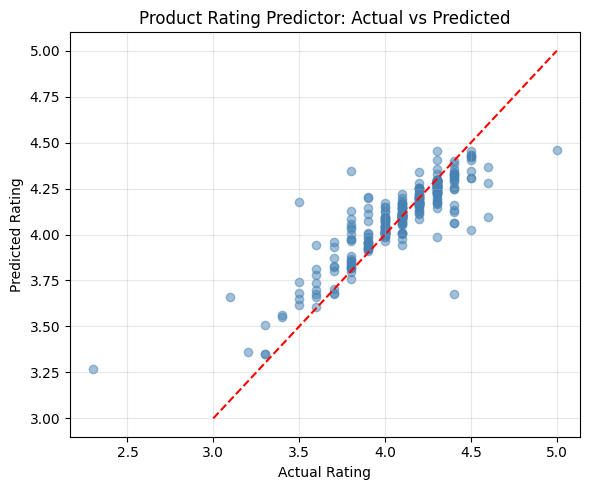

R² Score: 0.728
MAE: 0.089


In [18]:
# Visualizing Actual vs Predicted Ratings
# Scatter plot showing how close predictions are to actual ratings. The red dashed line shows perfect prediction.

import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([3, 5], [3, 5], 'r--', linewidth=1.5)
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Product Rating Predictor: Actual vs Predicted')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")